# 2. NLP + Model Training 

## 2.1 Packages importeren 

In [1]:
import pandas as pd 
import re 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

## 2.2 Dataset inladen 
Alleen de kolommen "Omschrijving" en "Product" worden gebruikt voor de modeltraining. "ID", "Datum_ontvangst" en "Antwoord_bedrijf" voegen geen voorspellende waarde toe. 

In [2]:
df = pd.read_csv('klachten.csv').copy()
y = df['Product']
X = df['Omschrijving']

## 2.3 Preprocessing functies 

In [3]:
stop_words = set(stopwords.words('english')) # initialiseren van stopwoorden met Engelse stopwoorden
lemmatizer = WordNetLemmatizer() # initialiseren van lemmatizer met WordNetLemmatizer

In [4]:
def preprocess_text(text):
    '''Preprocess tekst door te lowercasen en speciale tekens te verwijderen.'''
    if pd.isna(text): # als de tekst ontbreekt, retourneer een lege string
        return"" 
    text = text.lower() # lowercase maken 
    text = re.sub(r'[^a-z\s]', ' ', text) # speciale tekens verwijderen 
    return text 

In [5]:
def my_tokenizer(text):
    '''Tokenize tekst, verwijder stopwoorden en lemmatize tokens.'''
    tokens = word_tokenize(text) # tokenizen
    tokens = [t for t in tokens if not re.fullmatch(r"x+", t.lower())] # verwijderen van tokens die alleen uit 'x' bestaan 
    tokens = [t for t in tokens if t not in stop_words] # verwijderen van stopwoorden
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # lemmatizen
    return tokens

## 2.4 Tokenanalyse

### 2.4.1 Alle tokens verkrijgen

In [6]:
def get_all_tokens(df):
    '''Functie die alle tokens teruggeeft'''
    all_tokens = []
    for text in df['Omschrijving']:
        clean = preprocess_text(text)
        tokens = my_tokenizer(clean)
        all_tokens.extend(tokens)
    return all_tokens

all_tokens = get_all_tokens(df)

### 2.4.2 Meest voorkomende tokens

In [7]:
word_counts = Counter(all_tokens).most_common(20)
print(word_counts)

[('account', 20326), ('credit', 20188), ('payment', 14502), ('loan', 10212), ('would', 9991), ('bank', 9805), ('report', 9117), ('time', 8989), ('debt', 8801), ('told', 7907), ('n', 7425), ('information', 7337), ('company', 7318), ('card', 7237), ('received', 7115), ('call', 6959), ('mortgage', 6911), ('letter', 6292), ('day', 6143), ('called', 6041)]


### 2.4.3 Wordcloud alle klachten 

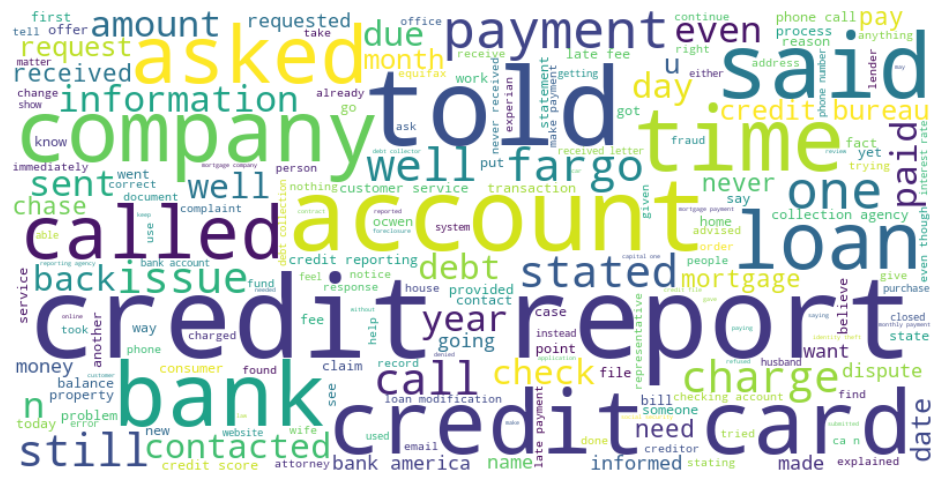

In [8]:
text_blob = " ".join(all_tokens)
wc = WordCloud(width=800, height=400, background_color="white").generate(text_blob)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

In [9]:
# Sla de woordfrequenties op in een CSV-bestand
freq_df = pd.DataFrame(word_counts, columns=['woord', 'frequentie'])
freq_df.to_csv("woord_frequenties.csv", index=False)

### 2.4.4 Wordclouds per product sector

In [10]:
def get_tokens_for_product(df, product):
    subset = df[df['Product'] == product]['Omschrijving']
    tokens = []
    for text in subset:
        clean = preprocess_text(text)
        tokens.extend(my_tokenizer(clean))
    return tokens

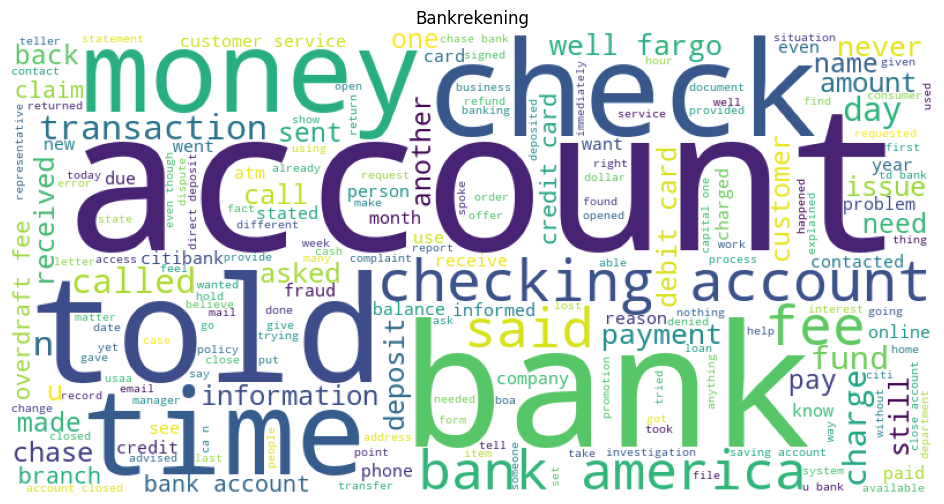

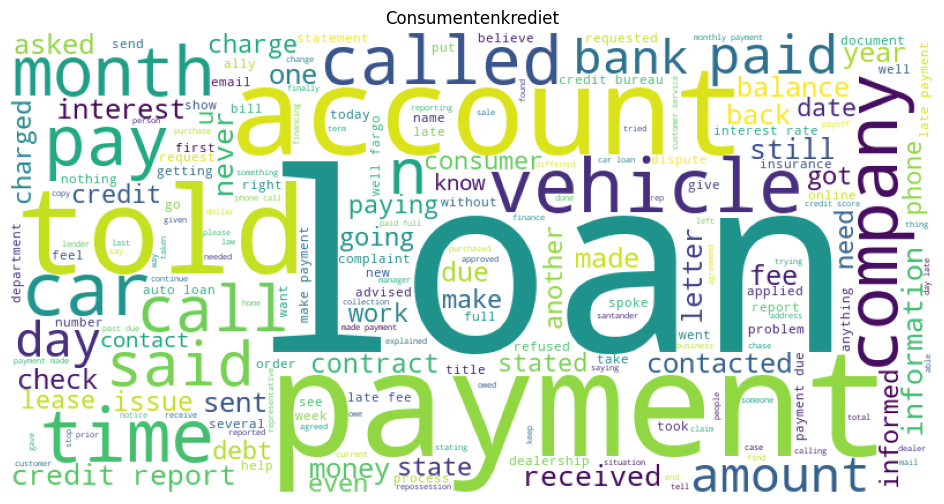

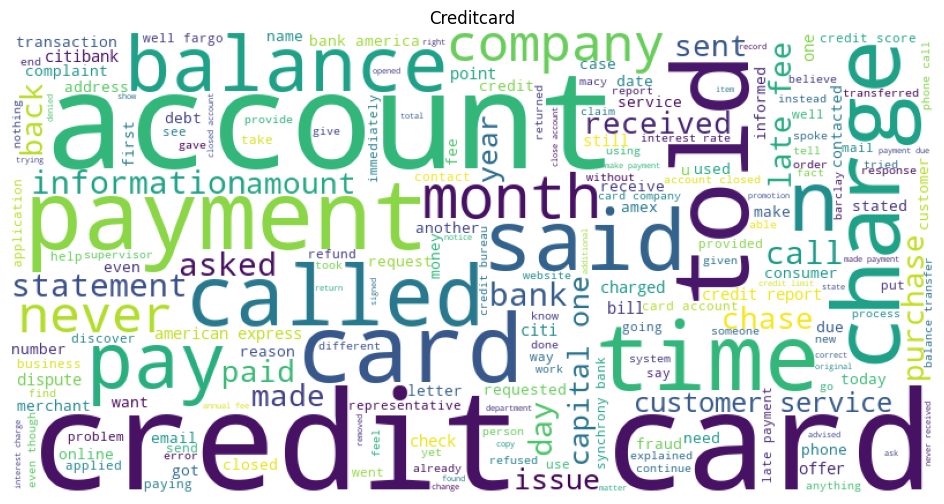

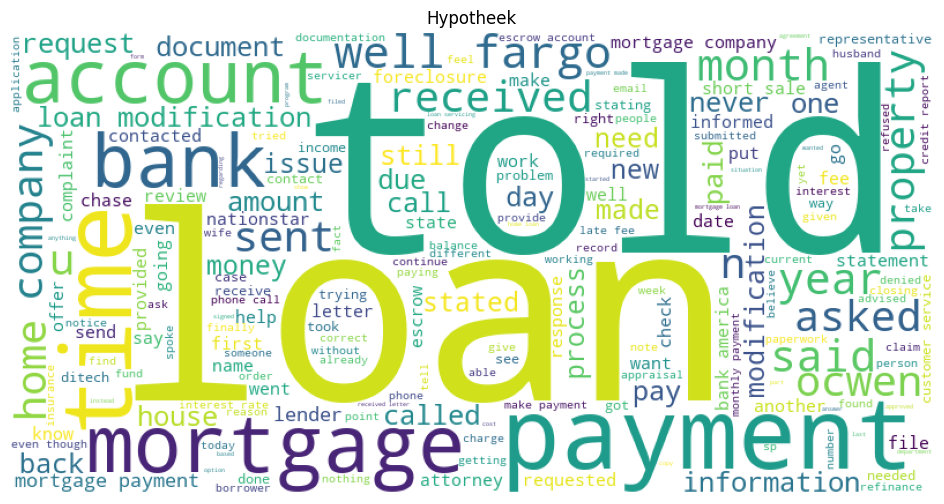

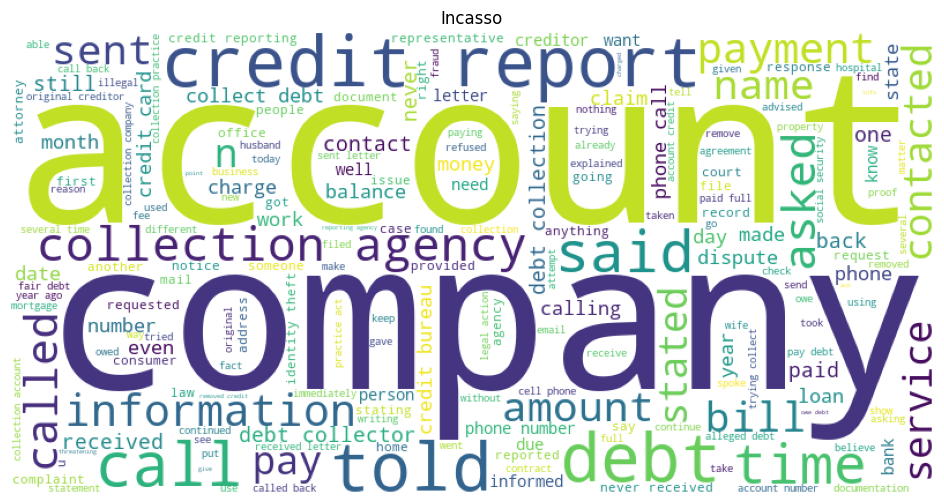

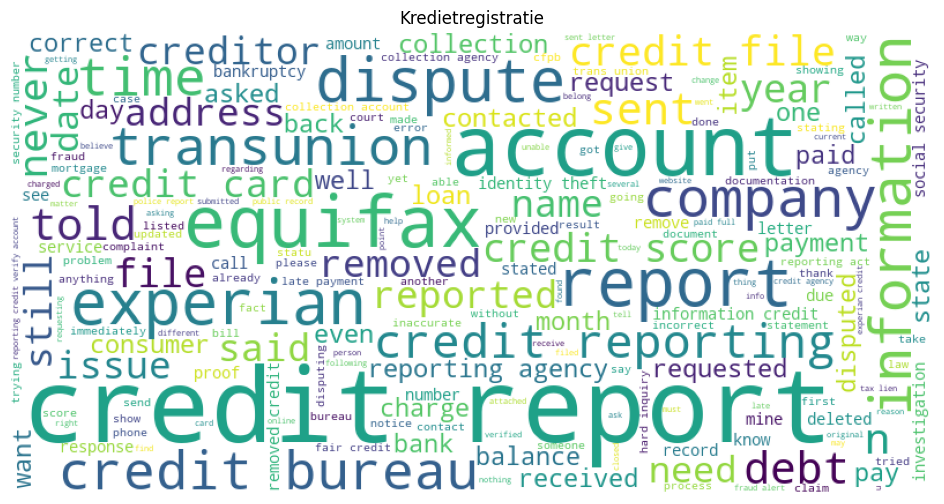

In [11]:
for product in df['Product'].unique():
    tokens = get_tokens_for_product(df, product)
    wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(tokens))
    plt.figure(figsize=(12,6))
    plt.imshow(wc)
    plt.title(product)
    plt.axis("off")
    plt.show()

## 2.5 Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

## 2.6 Pipeline

In [13]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer( # TF-IDF vectorizer met aangepaste preprocessor en tokenizer
        preprocessor=preprocess_text,
        tokenizer=my_tokenizer,
        analyzer='word', # werken op woordniveau
        token_pattern=None # uitschakelen van standaard token patroon omdat we een aangepaste tokenizer gebruiken
    )),
    ('model', LogisticRegression(max_iter=10000))
])

## 2.7 Logistic Regression model trainen + voorspellingen doen

In [14]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

## 2.8 Evaluatie Logistic Regression model

### 2.8.1 Confusion Matrix 

[[ 371    2   33   14   16   11]
 [   8  138   12   27   71   28]
 [  30    0  441   12   53   29]
 [  10    4    4  942   18   16]
 [   9   14   20   31 1063   92]
 [   4   11   28   13   94  798]]


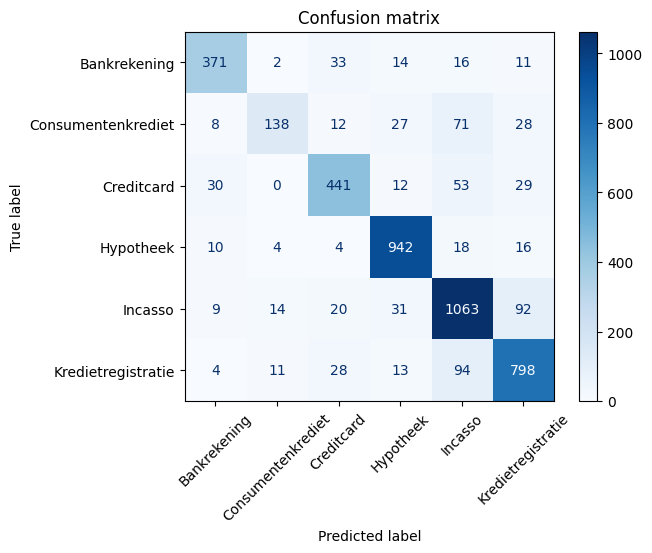

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.show()


### 2.8.2 F1-score

In [16]:
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", f1)

F1: 0.8367088789030991


### 2.8.3 AUC-score (multiclass)

In [17]:
auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
print("AUC:", auc)

AUC: 0.9665087030722557


### 2.8.4 ROC curve per productsector

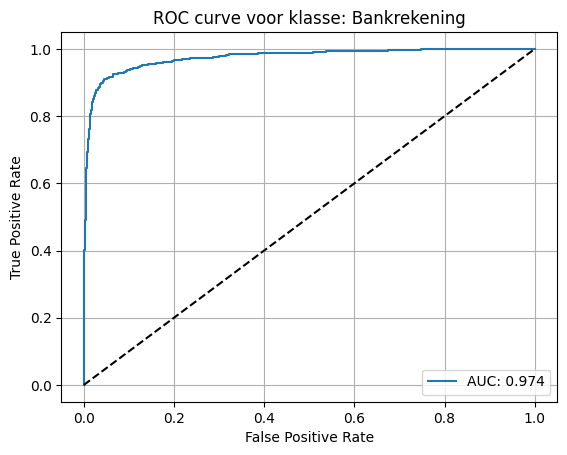

In [18]:
classes = pipeline['model'].classes_

class_name = classes[0]  # index veranderen om andere klassen te bekijken
class_index = list(classes).index(class_name)

# binary labels maken
y_binary = (y_test == class_name).astype(int)
proba_class = y_proba[:, class_index]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_binary, proba_class)

# AUC voor de specifieke klasse
auc_class = roc_auc_score(y_binary, proba_class)

plt.plot(fpr, tpr, label=f'AUC: {auc_class:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve voor klasse: {class_name}")
plt.legend()
plt.grid(True)
plt.show()